<a href="https://colab.research.google.com/github/KoaLe108/PTDLvHS/blob/main/ePillID_tutorial_colab_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ePillID-benchmark

* https://github.com/usuyama/ePillID-benchmark
* https://arxiv.org/abs/2005.14288


```
@inproceedings{usuyama2020epillid,
  title={ePillID Dataset: A Low-Shot Fine-Grained Benchmark for Pill Identification},
  author={Usuyama, Naoto and Delgado, Natalia Larios and Hall, Amanda K and Lundin, Jessica},
  booktitle={Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition Workshops},
  year={2020}
}
```

In [1]:
import os

if not os.path.exists("ePillID-benchmark"):
  !git clone https://github.com/usuyama/ePillID-benchmark.git

Cloning into 'ePillID-benchmark'...
remote: Enumerating objects: 122, done.
remote: Counting objects: 100% (122/122), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 122 (delta 36), reused 95 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (122/122), 432.31 KiB | 13.51 MiB/s, done.
Resolving deltas: 100% (36/36), done.


## Download the data and unzip

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip -q "/content/drive/MyDrive/PTDLvHS/ePillID_data.zip" -d "/content/"

In [4]:
if not os.path.exists("train_cv.py"):
  %cd ePillID-benchmark/src

!echo `pwd`
!ls

/content/ePillID-benchmark/src
/content/ePillID-benchmark/src
arguments.py	       metrics.py	    multihead_trainer.py  train_nocv.py
classif_utils.py       metric_test_eval.py  pillid_datasets.py
configs		       metric_utils.py	    sanitytest_eval.py
image_augmentators.py  models		    train_cv.py


## Enabling GPU on Colab

Need to enable GPU from Notebook settings

- Navigate to Edit-Notebook settings menu
- Select GPU from the Hardware Accelerator dropdown list


## Install dependencies

The library versions on Colab might be different from what we used in our experiments. Check our repo for full dependencies
 https://github.com/usuyama/ePillID-benchmark/tree/master/docker

In [5]:
!sudo apt-get update -y
!sudo apt-get install python3.10 python3.10-dev python3.10-distutils
!sudo update-alternatives --install /usr/bin/python3 python3 /usr/bin/python3.10 1
!sudo update-alternatives --set python3 /usr/bin/python3.10
!curl https://bootstrap.pypa.io/get-pip.py -o get-pip.py
!python3 get-pip.py --force-reinstall

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,475 kB]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,955 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Pa

In [6]:
!python --version

Python 3.10.12


In [7]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 16.7 MB/s  0:00:20
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 151.1 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 152.9 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 172.3 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 49.6 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 173.6 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB ?  0:01:04
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 64.0 MB/s  0:00:05
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 69.5 MB/s  0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 63.3 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 65.1 MB/s  0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 67.3 MB/s  0:00:02

In [8]:
!pip install pandas matplotlib scikit-learn tqdm opencv-python pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 101.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 128.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 134.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 60.8 MB/s  0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 153.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 96.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 70.2 MB/s  0:00:00
  Attempting uninstall: pyparsing
    Found existing installation: pyparsing 2.4.7
    Uninstalling pyparsing-2.4.7:
      Successfully uninstalled pyparsing-2.4.7
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [matplotlib]


In [9]:
!pip install "imgaug==0.4.0" "numpy<1.24.0" "pandas<2.0.0" "scipy<1.13.0" --force-reinstall

  Using cached pillow-12.1.1-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached matplotlib-3.10.8-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
INFO: pip is looking at multiple versions of scikit-image to determine which version is compatible with other requirements. This could take a while.
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached packaging-26.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.w

In [10]:
# Sửa lỗi collections.Iterable thành collections.abc.Iterable
!sed -i 's/collections.Iterable/collections.abc.Iterable/g' /usr/local/lib/python3.10/dist-packages/imgaug/imgaug.py
!sed -i 's/collections.Iterable/collections.abc.Iterable/g' /usr/local/lib/python3.10/dist-packages/imgaug/augmenters/meta.py

# Sửa lỗi kiểu dữ liệu NumPy cũ (np.bool, np.float) sang kiểu chuẩn của Python
!sed -i 's/np\.bool/bool/g' /usr/local/lib/python3.10/dist-packages/imgaug/augmenters/meta.py
!sed -i 's/np\.float/float/g' /usr/local/lib/python3.10/dist-packages/imgaug/augmenters/meta.py
!sed -i 's/np\.int/int/g' /usr/local/lib/python3.10/dist-packages/imgaug/augmenters/meta.py

In [12]:
!grep -r "num_workers" /content/ePillID-benchmark/src/ -l | xargs sed -i 's/num_workers=[0-9]*/num_workers=2/g'

In [11]:
!pip install azureml-sdk

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.2/26.2 MB 138.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 171.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 MB 72.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 770.3/770.3 kB 40.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 145.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 67.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 100.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 614.0/614.0 kB 34.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 151.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 141.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 92.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [13]:
!pip list

Package                              Version
------------------------------------ ---------------
adal                                 1.2.7
applicationinsights                  0.11.10
argcomplete                          3.6.3
attrs                                26.1.0
azure-common                         1.1.28
azure-core                           1.39.0
azure-graphrbac                      0.61.2
azure-identity                       1.17.0
azure-mgmt-authorization             4.0.0
azure-mgmt-containerregistry         14.0.0
azure-mgmt-core                      1.6.0
azure-mgmt-keyvault                  11.0.0
azure-mgmt-network                   30.0.0
azure-mgmt-resource                  24.0.0
azure-mgmt-storage                   24.0.0
azureml-automl-core                  1.62.0
azureml-core                         1.61.0.post3
azureml-dataprep                     5.4.3
azureml-dataprep-native              42.1.0
azureml-dataprep-rslex               2.25.3
azureml-dataset-runt

## Run training and evaluation using resnet18

In [14]:
!MPLBACKEND=Agg python /content/ePillID-benchmark/src/train_nocv.py \
--appearance_network resnet18 \
--pooling CBP \
--max_epochs 100 \
--batch_size 24 \
--data_root_dir /content/ePillID_data \
--results_dir /content/ePillID_data/classification_results

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_ranking.py:1046: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/m

In [15]:
# Check predictions
!ls outputs

eval_predictions_pilltypeid_nih_sidelbls0.01_metric_5folds_3.csv


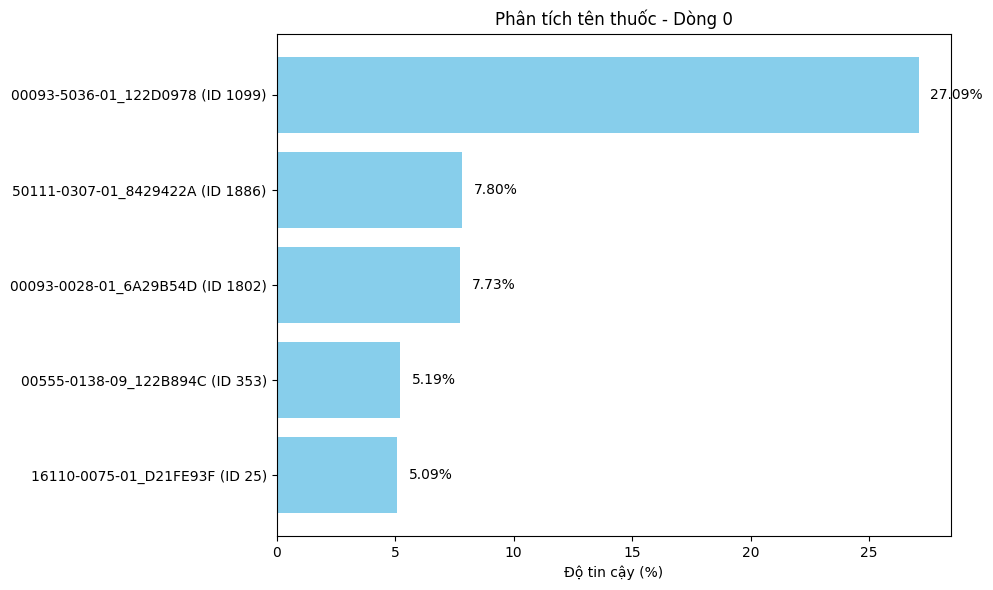

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Đường dẫn các file (Dựa trên cấu trúc thư mục của bạn)
csv_results = "/content/ePillID_data/classification_results/lr0.0001_dr0.0_lrpatience2_lrfactor0.5_resnet18_202604011202/eval_predictions_pilltypeid_nih_sidelbls0.01_metric_5folds_3.csv"
labels_file = "/content/ePillID_data/all_labels.csv"

# 2. Đọc dữ liệu
df_results = pd.read_csv(csv_results)
df_labels = pd.read_csv(labels_file)

def plot_final_analysis(row_index):
    row = df_results.iloc[row_index]

    # Xử lý chuỗi score (tách theo dấu cách để tránh lỗi SyntaxError)
    raw_score_str = row['score'].strip('[]')
    scores = np.fromstring(raw_score_str, sep=' ')

    # Lấy Top 5 kết quả cao nhất
    top5_indices = scores.argsort()[-5:][::-1]
    top5_values = scores[top5_indices] * 100

    pill_names = []
    for idx in top5_indices:
        # Tra cứu tên thuốc bằng chỉ số index
        # Vì file nhãn của bạn không có cột catid, ta dùng index của dòng
        if idx < len(df_labels):
            name = df_labels.iloc[idx]['pilltype_id']
            pill_names.append(f"{name} (ID {idx})")
        else:
            pill_names.append(f"Unknown (ID {idx})")

    # 3. Vẽ biểu đồ thanh ngang
    plt.figure(figsize=(10, 6))
    bars = plt.barh(pill_names, top5_values, color='skyblue')

    plt.xlabel('Độ tin cậy (%)')
    plt.title(f"Phân tích tên thuốc - Dòng {row_index}")
    plt.gca().invert_yaxis()

    # Thêm số % vào đầu mỗi thanh
    for bar in bars:
        plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.2f}%', va='center')

    plt.tight_layout()
    plt.show()

# Chạy thử với dòng đầu tiên
plot_final_analysis(0)

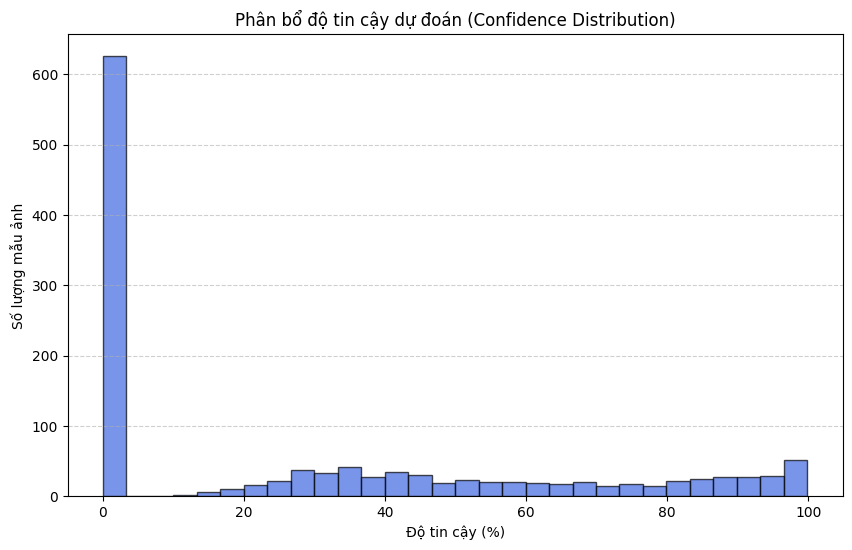

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Đọc file kết quả (Sử dụng đường dẫn file .csv của bạn)
df = pd.read_csv("/content/ePillID_data/classification_results/lr0.0001_dr0.0_lrpatience2_lrfactor0.5_resnet18_202604011202/eval_predictions_pilltypeid_nih_sidelbls0.01_metric_5folds_3.csv")

# Trích xuất độ tin cậy cao nhất từ cột 'score'
confidences = []
for s in df['score']:
    scores = np.fromstring(s.strip('[]'), sep=' ')
    confidences.append(np.max(scores) * 100)

plt.figure(figsize=(10, 6))
plt.hist(confidences, bins=30, color='royalblue', edgecolor='black', alpha=0.7)
plt.title('Phân bổ độ tin cậy dự đoán (Confidence Distribution)')
plt.xlabel('Độ tin cậy (%)')
plt.ylabel('Số lượng mẫu ảnh')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [43]:
import pandas as pd
import numpy as np

# Sử dụng đường dẫn file kết quả của bạn
csv_path = "/content/ePillID_data/classification_results/lr0.0001_dr0.0_lrpatience2_lrfactor0.5_resnet18_202604011202/eval_predictions_pilltypeid_nih_sidelbls0.01_metric_5folds_3.csv"
df = pd.read_csv(csv_path)

def calculate_topk_accuracy(df):
    top1_correct = 0
    top5_correct = 0
    total = len(df)

    for _, row in df.iterrows():
        # Xử lý chuỗi score (tách theo khoảng trắng do lỗi Syntax trước đó)
        scores = np.fromstring(row['score'].strip('[]'), sep=' ')
        correct_idx = int(row['correct_index'])

        # Kiểm tra Top-1
        if np.argmax(scores) == correct_idx:
            top1_correct += 1

        # Kiểm tra Top-5
        top5_indices = scores.argsort()[-5:]
        if correct_idx in top5_indices:
            top5_correct += 1

    print(f"Top-1 Accuracy: {(top1_correct/total)*100:.2f}%")
    print(f"Top-5 Accuracy: {(top5_correct/total)*100:.2f}%")

calculate_topk_accuracy(df)

Top-1 Accuracy: 50.80%
Top-5 Accuracy: 78.19%


In [47]:
from collections import Counter

error_pairs = []
for _, row in df.iterrows():
    scores = np.fromstring(row['score'].strip('[]'), sep=' ')
    pred_idx = np.argmax(scores)
    correct_idx = int(row['correct_index'])

    if pred_idx != correct_idx:
        error_pairs.append(f"Thực tế ID {correct_idx} -> Nhầm thành ID {pred_idx}")

print("Top 5 cặp thuốc hay bị nhầm nhất:")
for pair, count in Counter(error_pairs).most_common(5):
    print(f"{pair}: {count} lần")

Top 5 cặp thuốc hay bị nhầm nhất:
Thực tế ID 547 -> Nhầm thành ID 546: 12 lần
Thực tế ID 416 -> Nhầm thành ID 281: 11 lần
Thực tế ID 2015 -> Nhầm thành ID 2014: 10 lần
Thực tế ID 330 -> Nhầm thành ID 329: 10 lần
Thực tế ID 295 -> Nhầm thành ID 289: 9 lần


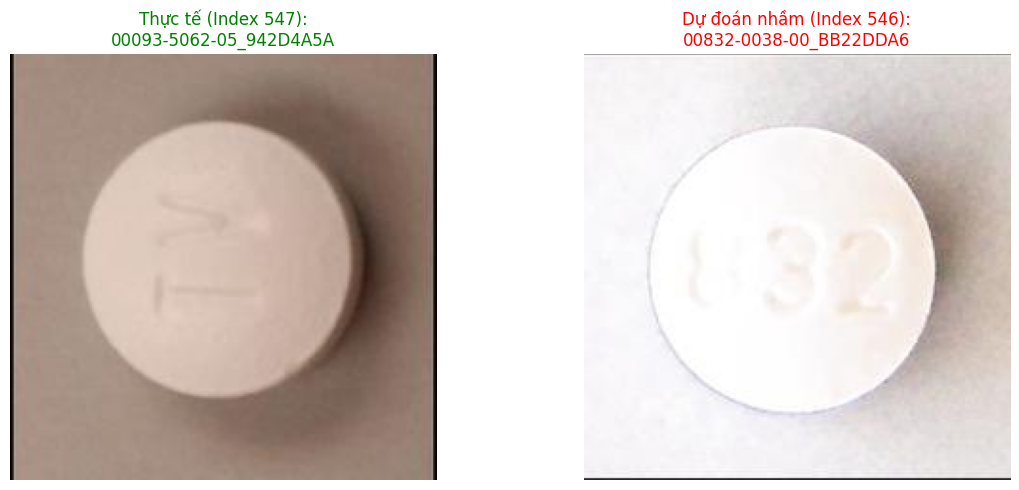

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# 1. Định nghĩa đường dẫn gốc (Thay đổi nếu thư mục ảnh của bạn nằm chỗ khác)
dataset_root = "/content/ePillID_data/classification_data/"
df_labels = pd.read_csv("/content/ePillID_data/all_labels.csv")

def compare_actual_images_fixed(true_idx, pred_idx):
    try:
        actual_row = df_labels.iloc[true_idx]
        pred_row = df_labels.iloc[pred_idx]

        # 2. Nối đường dẫn gốc với đường dẫn trong CSV
        true_img_path = os.path.join(dataset_root, actual_row['image_path'])
        pred_img_path = os.path.join(dataset_root, pred_row['image_path'])

        # Kiểm tra file có tồn tại không trước khi đọc
        if not os.path.exists(true_img_path):
            print(f"❌ Không tìm thấy ảnh thực tế tại: {true_img_path}")
            return

        fig, ax = plt.subplots(1, 2, figsize=(12, 5))

        ax[0].imshow(mpimg.imread(true_img_path))
        ax[0].set_title(f"Thực tế (Index {true_idx}):\n{actual_row['pilltype_id']}", color='green')
        ax[0].axis('off')

        ax[1].imshow(mpimg.imread(pred_img_path))
        ax[1].set_title(f"Dự đoán nhầm (Index {pred_idx}):\n{pred_row['pilltype_id']}", color='red')
        ax[1].axis('off')

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Lỗi: {e}")

# Chạy thử với cặp lỗi hay gặp nhất của bạn
compare_actual_images_fixed(547, 546)

In [56]:
# df là DataFrame đọc từ file eval_predictions...csv của bạn
print(f"Tổng số mẫu thử nghiệm trong báo cáo: {len(df)}")

Tổng số mẫu thử nghiệm trong báo cáo: 1252
